### Imports and Configuration


In [ ]:
# Import shared libraries, metrics, and utilities used by all later stages of this notebook.
# Keep metric definitions centralized so split evaluation and cross-validation are computed consistently.
# Configure warnings once to keep long experiment output readable during repeated runs.

import numpy as np
import pandas as pd
import joblib
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, fbeta_score)


### Paths and Data Loading


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from pathlib import Path

# Build project-relative paths to keep the notebook portable across environments and machines.
# Load the prepared UNSW train/validation/test splits so every model is benchmarked on identical partitions.
# Ensure output directories exist before training so artifact persistence does not fail at the end.

# Determine BASE_DIR using a robust search strategy
cwd = Path('/content/drive/MyDrive/MLmodeling/XAI')
if (cwd / 'models').exists() and (cwd / 'features').exists():
    BASE_DIR = cwd
elif (cwd.parent / 'models').exists() and (cwd.parent / 'features').exists():
    BASE_DIR = cwd.parent
elif len(cwd.parents) > 1 and (cwd.parents[1] / 'models').exists() and (cwd.parents[1] / 'features').exists():
    BASE_DIR = cwd.parents[1]
else:
    # Fallback to the default expected location if the project structure isn't immediately found
    # This might need adjustment if your project is structured differently.
    BASE_DIR = Path('/content/drive/MyDrive/MLmodeling/XAI')

SPLITS_DIR = BASE_DIR / "splits" / "UNSW-NB15"
MODEL_DIR  = BASE_DIR / "models" / "UNSW-NB15"
RESULT_DIR = BASE_DIR / "results" / "UNSW-NB15"
MODEL_DIR.mkdir(parents=True, exist_ok=True)
RESULT_DIR.mkdir(parents=True, exist_ok=True)

# sklearn artifacts in models/UNSW-NB15/*.pkl were trained on the first 188 OHE columns.
# Current X_*.csv may list 192 columns (4 extra trailing state_* one-hots).
UNSW_MODEL_N_FEATURES = 188

def _unsw_X_csv_to_values(path):
    df = pd.read_csv(path)
    n = df.shape[1]
    if n > UNSW_MODEL_N_FEATURES:
        df = df.iloc[:, :UNSW_MODEL_N_FEATURES]
    elif n < UNSW_MODEL_N_FEATURES:
        raise ValueError(
            f"{path.name}: need >= {UNSW_MODEL_N_FEATURES} columns to match saved models, got {n}"
        )
    return df.values

X_train = _unsw_X_csv_to_values(SPLITS_DIR / "X_train.csv")
X_val   = _unsw_X_csv_to_values(SPLITS_DIR / "X_val.csv")
X_test  = _unsw_X_csv_to_values(SPLITS_DIR / "X_test.csv")

y_train = pd.read_csv(SPLITS_DIR / "y_train.csv").squeeze()
y_val   = pd.read_csv(SPLITS_DIR / "y_val.csv").squeeze()
y_test  = pd.read_csv(SPLITS_DIR / "y_test.csv").squeeze()

print(f"Train : {X_train.shape} | Attack ratio: {y_train.mean():.2%}")
print(f"Val   : {X_val.shape}   | Attack ratio: {y_val.mean():.2%}")
print(f"Test  : {X_test.shape}  | Attack ratio: {y_test.mean():.2%}")

Train : (180371, 188) | Attack ratio: 63.91%
Val   : (38651, 188)   | Attack ratio: 63.91%
Test  : (38651, 188)  | Attack ratio: 63.91%


### Model Definition


In [ ]:
# Define LOF with explicit hyperparameters so this experiment remains easy to reproduce and compare.
# Keep model initialization isolated from training/evaluation so tuning changes stay localized to one place.
# `novelty=True` allows scoring unseen validation/test samples after fitting on training data.

ARTIFACT_NAME = "UNSW_16_LOF"
MODEL_NAME = "LOF"
# UNSW-NB15 train is 55% attack   attack is the majority class.
# LOF treats the majority as inliers, so we flip:
#   normal traffic = rare = outlier = LOF outputs -1
#   attack traffic = majority = inlier = LOF outputs +1
# contamination = ~45% normal ratio in train
model = LocalOutlierFactor(
    n_neighbors=20,
    contamination=0.45,    # ~45% normal (minority) in UNSW-NB15 train
    novelty=True,
    algorithm='ball_tree',
    leaf_size=40,
    n_jobs=-1
)


### Train and Evaluate


In [ ]:
# Fit the model and evaluate train/validation/test in one flow to quickly reveal overfitting or underfitting.
# Report threshold metrics (accuracy, precision, recall, F1, F2) and ranking metrics (ROC-AUC, PR-AUC) together.
# PR-AUC is especially informative for imbalanced attack detection, so it complements ROC-AUC in this setting.

# UNSW-NB15 train is only 82k rows   no sampling needed for LOF
print("Fitting LOF   this may take a few minutes...")
model.fit(X_train)
print("Fitting complete.")

def predict_binary(model, X):
    # Flipped: -1 = outlier = NORMAL (0),  +1 = inlier = ATTACK (1)
    return np.where(model.predict(X) == -1, 0, 1)

print("Predicting on train...")
y_pred_train = predict_binary(model, X_train)
print("Predicting on val...")
y_pred_val   = predict_binary(model, X_val)
print("Predicting on test...")
y_pred_test  = predict_binary(model, X_test)

def eval_unsupervised(y_true, y_pred, split_name):
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)
    f2   = fbeta_score(y_true, y_pred, beta=2, zero_division=0)
    print(f"{split_name:6s}   Accuracy: {acc:.4f} | Precision: {prec:.4f} | "
          f"Recall: {rec:.4f} | F1: {f1:.4f} | F2: {f2:.4f}")

eval_unsupervised(y_train, y_pred_train, "Train")
eval_unsupervised(y_val,   y_pred_val,   "Val")
eval_unsupervised(y_test,  y_pred_test,  "Test")


Fitting LOF   this may take a few minutes...
Fitting complete.
Predicting on train...
Predicting on val...
Predicting on test...
Train    Accuracy: 0.5286 | Precision: 0.6462 | Recall: 0.5799 | F1: 0.6113 | F2: 0.5921
Val      Accuracy: 0.5195 | Precision: 0.6457 | Recall: 0.5497 | F1: 0.5938 | F2: 0.5665
Test     Accuracy: 0.5234 | Precision: 0.6508 | Recall: 0.5487 | F1: 0.5954 | F2: 0.5665


### Model Evaluation (Unsupervised - No cross validation)

In [ ]:
# LOF is an unsupervised learning model.
# It does not use labeled data (y), so techniques like Stratified K-Fold CV
# cannot be applied because they rely on class labels to split data.

# In unsupervised learning:
# - There is no ground truth for validation during training
# - Metrics like F1, ROC require true labels, which are not available
# - Hence, traditional cross-validation is not applicable

# Instead, we evaluate stability using:
# - Train / Validation / Test consistency
# - Distribution of anomaly scores
# - Domain-based validation (if labels available externally)

cv_results = {
    "cv_train_f1_mean": None,
    "cv_val_f1_mean":   None,
    "cv_val_f1_std":    None,
    "cv_val_roc_mean":  None,
    "cv_val_pr_mean":   None,
    "cv_gap":           None,
}
train_test_gap = None
print("CV skipped   unsupervised model")
print("Stability assessed via train / val / test consistency")



CV skipped   unsupervised model
Stability assessed via train / val / test consistency


### Save Results and Model Artifact


In [ ]:
# Assemble a standardized result row so this notebook aligns with the shared results schema.
# Save this notebook's latest metrics snapshot to CSV (default `to_csv` behavior overwrites the file on rerun).
# Persist the trained model artifact for downstream interpretability and analysis workflows such as SHAP and LIME.

row = {
    "dataset":         "UNSW-NB15",
    "model":           MODEL_NAME,
    "split":           "70/15/15",
    "test_accuracy":   round(accuracy_score(y_test, y_pred_test), 6),
    "test_precision":  round(precision_score(y_test, y_pred_test, zero_division=0), 6),
    "test_recall":     round(recall_score(y_test, y_pred_test, zero_division=0), 6),
    "test_f1":         round(f1_score(y_test, y_pred_test, zero_division=0), 6),
    "test_f2":         round(fbeta_score(y_test, y_pred_test, beta=2, zero_division=0), 6),
    "test_roc_auc":    None,
    "test_pr_auc":     None,
    "val_f1":          round(f1_score(y_val, y_pred_val, zero_division=0), 6),
    "val_f2":          round(fbeta_score(y_val, y_pred_val, beta=2, zero_division=0), 6),
    "val_roc_auc":     None,
    "val_pr_auc":      None,
    "train_f1":        round(f1_score(y_train, y_pred_train, zero_division=0), 6),
    "cv_val_f1_mean":  None,
    "cv_val_f1_std":   None,
    "cv_val_roc_mean": None,
    "cv_val_pr_mean":  None,
    "cv_gap":          None,
    "train_test_gap":  None,
}

pd.DataFrame([row]).to_csv(RESULT_DIR / f"{ARTIFACT_NAME}.csv", index=False)
joblib.dump(model, MODEL_DIR / f"{ARTIFACT_NAME}.pkl")
print(f"{ARTIFACT_NAME}   saved.")
print(pd.DataFrame([row]).T.to_string(header=False))


UNSW_16_LOF   saved.
dataset          UNSW-NB15
model                  LOF
split             70/15/15
test_accuracy     0.523402
test_precision    0.650773
test_recall       0.548682
test_f1           0.595383
test_f2           0.566455
test_roc_auc          None
test_pr_auc           None
val_f1            0.593829
val_f2            0.566511
val_roc_auc           None
val_pr_auc            None
train_f1          0.611261
cv_val_f1_mean        None
cv_val_f1_std         None
cv_val_roc_mean       None
cv_val_pr_mean        None
cv_gap                None
train_test_gap        None


## Inference
Use the saved anomaly model to classify a single row as **INLIER/NORMAL** or **OUTLIER/ATTACK**.

In [ ]:
# Setup for standalone anomaly inference
import json
from pathlib import Path

import numpy as np
import pandas as pd
import joblib
import ipywidgets as widgets
from IPython.display import display, HTML, clear_output



cwd = Path('/content/drive/MyDrive/MLmodeling/XAI')

if (cwd / 'models').exists() and (cwd / 'features').exists():
    BASE_DIR = cwd
elif (cwd.parent / 'models').exists() and (cwd.parent / 'features').exists():
    BASE_DIR = cwd.parent
elif len(cwd.parents) > 1 and (cwd.parents[1] / 'models').exists() and (cwd.parents[1] / 'features').exists():
    BASE_DIR = cwd.parents[1]
else:
    BASE_DIR = cwd

FEATURES_FILE = BASE_DIR / 'features' / 'UNSW-NB15_features.json'
MODEL_FILE = BASE_DIR / 'models' / 'UNSW-NB15' / 'UNSW_16_LOF.pkl'
SPLIT_DIR = BASE_DIR / 'splits' / 'UNSW-NB15'

assert FEATURES_FILE.exists(), f'Feature defaults not found: {FEATURES_FILE}'
assert MODEL_FILE.exists(), f'Model file not found: {MODEL_FILE}'

with open(FEATURES_FILE, 'r', encoding='utf-8') as f:
    UNSW_DEFAULTS = json.load(f)

EXCLUDE_COLS = {'id', 'attack_cat', 'label'}
UNSW_DEFAULTS = {k: v for k, v in UNSW_DEFAULTS.items() if k not in EXCLUDE_COLS}

INFER_MODEL = joblib.load(MODEL_FILE)

INFER_PREPROCESSOR = None
for pp_name in ('preprocessor.joblib', 'preprocessor.pkl'):
    pp_path = SPLIT_DIR / pp_name
    if pp_path.exists():
        INFER_PREPROCESSOR = joblib.load(pp_path)
        break

print(f'Loaded model: {MODEL_FILE.name}')
print(f'Model type: {type(INFER_MODEL).__name__}')
print(f'Feature defaults: {len(UNSW_DEFAULTS)}')
print(f'Preprocessor loaded: {INFER_PREPROCESSOR is not None}')


Loaded model: UNSW_16_LOF.pkl
Model type: LocalOutlierFactor
Feature defaults: 42
Preprocessor loaded: True


In [ ]:
# Build interactive UNSW form and predict NORMAL/ATTACK.
if 'UNSW_DEFAULTS' not in globals():
    print('Run the previous widget setup cell first.')
else:
    # Clear prior output area from this cell on rerun.
    clear_output(wait=True)

    # If this cell is rerun, close the previous UI instance to avoid duplicate panels.
    _ui_key = f"_UNSW_INFER_UI_{globals().get('ARTIFACT_NAME', 'UNSW')}"
    _prev_ui = globals().get(_ui_key, None)
    if _prev_ui is not None:
        try:
            _prev_ui.close()
        except Exception:
            pass

    input_widgets = {}

    def make_widget(default):
        if isinstance(default, str):
            return widgets.Text(value=str(default), layout=widgets.Layout(width='360px', min_width='300px', height='34px'))
        if isinstance(default, int) and not isinstance(default, bool):
            return widgets.IntText(value=int(default), layout=widgets.Layout(width='360px', min_width='300px', height='34px'))
        return widgets.FloatText(value=float(default), step=0.01, layout=widgets.Layout(width='360px', min_width='300px', height='34px'))

    def to_group_name(col_name):
        if '.' in col_name:
            return col_name.split('.', 1)[0]
        if '_' in col_name:
            return col_name.split('_', 1)[0]
        return 'other'

    feature_groups = {}
    for col, default in UNSW_DEFAULTS.items():
        w = make_widget(default)
        input_widgets[col] = w
        group = to_group_name(col)
        feature_groups.setdefault(group, []).append(col)

    sorted_groups = sorted(feature_groups.keys())
    group_boxes = []

    for group in sorted_groups:
        rows = []
        for col in feature_groups[group]:
            label = widgets.HTML(
                value=f'<div style="font-family:monospace; font-size:13px;">{col}</div>',
                layout=widgets.Layout(width='430px', min_width='360px')
            )
            rows.append(
                widgets.HBox(
                    [label, input_widgets[col]],
                    layout=widgets.Layout(justify_content='space-between', width='100%')
                )
            )

        group_box = widgets.VBox(rows, layout=widgets.Layout(gap='8px', padding='8px 4px'))
        group_boxes.append(group_box)

    accordion = widgets.Accordion(
        children=group_boxes,
        layout=widgets.Layout(width='100%', max_height='560px', overflow_y='auto')
    )

    for i, group in enumerate(sorted_groups):
        accordion.set_title(i, f'{group} ({len(feature_groups[group])})')

    if sorted_groups:
        accordion.selected_index = 0

    group_selector = widgets.Dropdown(
        options=[(f'{g} ({len(feature_groups[g])})', i) for i, g in enumerate(sorted_groups)],
        description='Jump to:',
        style={'description_width': '80px'},
        layout=widgets.Layout(width='360px')
    )

    search_box = widgets.Text(
        value='',
        placeholder='Type feature name (e.g., sbytes, dttl) then press Enter',
        description='Find:',
        style={'description_width': '80px'},
        layout=widgets.Layout(width='620px')
    )

    predict_btn = widgets.Button(
        description='Predict',
        button_style='success',
        icon='check',
        layout=widgets.Layout(width='130px', height='36px')
    )
    reset_btn = widgets.Button(
        description='Reset',
        icon='refresh',
        layout=widgets.Layout(width='110px', height='36px')
    )

    # Single-render result surface: overwrite HTML value instead of stacking Output displays.
    result_html = widgets.HTML(value='')

    _busy_key = f"_UNSW_INFER_BUSY_{globals().get('ARTIFACT_NAME', 'UNSW')}"
    _last_click_key = f"_UNSW_INFER_LAST_CLICK_{globals().get('ARTIFACT_NAME', 'UNSW')}"
    globals()[_busy_key] = False
    globals()[_last_click_key] = 0.0

    def _set_result_message(msg, color='#444'):
        result_html.value = (
            f"<div style='border:1px solid #ddd; border-radius:8px; padding:10px; max-width:700px; color:{color};'>"
            f"{msg}"
            f"</div>"
        )

    def on_group_change(change):
        if change['name'] == 'value':
            accordion.selected_index = change['new']

    def on_find_submit(_):
        q = search_box.value.strip().lower()
        if not q:
            return
        for idx, group in enumerate(sorted_groups):
            for col in feature_groups[group]:
                if q in col.lower():
                    accordion.selected_index = idx
                    _set_result_message(f'Found in group: {group}. Scroll to locate "{col}".')
                    return
        _set_result_message(f'No feature matched "{q}".', color='#b71c1c')

    def _build_input_row():
        row = {}
        for c, d in UNSW_DEFAULTS.items():
            v = input_widgets[c].value
            if isinstance(d, str):
                row[c] = str(v)
            elif isinstance(d, int) and not isinstance(d, bool):
                row[c] = int(v)
            else:
                row[c] = float(v)
        return row

    def _prepare_X(df_input):
        X_proc = None
        if INFER_PREPROCESSOR is not None:
            X_proc = INFER_PREPROCESSOR.transform(df_input)

        if X_proc is None:
            expected_n = getattr(INFER_MODEL, 'n_features_in_', None)
            if INFER_FEATURE_NAMES is not None and (expected_n is None or len(INFER_FEATURE_NAMES) == int(expected_n)):
                X_proc = df_input.reindex(columns=[str(c) for c in INFER_FEATURE_NAMES], fill_value=0).astype(float).values
            elif hasattr(INFER_MODEL, 'feature_names_in_'):
                model_cols = [str(c) for c in INFER_MODEL.feature_names_in_]
                X_proc = df_input.reindex(columns=model_cols, fill_value=0).astype(float).values
            else:
                X_proc = df_input.select_dtypes(include=[np.number]).values

        expected_n = getattr(INFER_MODEL, 'n_features_in_', None)
        if expected_n is not None and X_proc.shape[1] != int(expected_n):
            if X_proc.shape[1] > int(expected_n):
                X_proc = np.asarray(X_proc)[:, :int(expected_n)]
            else:
                raise ValueError(f'Feature mismatch: expected {int(expected_n)}, got {X_proc.shape[1]}')

        if hasattr(INFER_MODEL, 'feature_names_in_') and X_proc.shape[1] == len(INFER_MODEL.feature_names_in_):
            return pd.DataFrame(X_proc, columns=[str(c) for c in INFER_MODEL.feature_names_in_])
        return X_proc

    def on_predict(_):
        import time as _time

        now = _time.perf_counter()
        last = float(globals().get(_last_click_key, 0.0))
        # Ignore duplicate click events arriving within a short window.
        if now - last < 0.25:
            return
        globals()[_last_click_key] = now

        if globals().get(_busy_key, False):
            return

        globals()[_busy_key] = True
        predict_btn.disabled = True
        try:
            row = _build_input_row()
            df_input = pd.DataFrame([row])
            X_input = _prepare_X(df_input)

            # Due to potential scikit-learn version incompatibility (observed warnings),
            # the loaded LogisticRegression model might be missing expected attributes.
            # Specifically, 'multi_class' is sometimes implicitly accessed by older versions
            # of scikit-learn when processing models saved by newer versions.
            # This is a heuristic fix to allow execution to proceed, assuming a binary classification.
            if not hasattr(INFER_MODEL, 'multi_class'):
                # For binary classification, 'ovr' is typically the default strategy.
                # This patch attempts to satisfy the attribute lookup.
                INFER_MODEL.multi_class = 'ovr'

            pred = int(INFER_MODEL.predict(X_input)[0])
            label = 'ATTACK' if pred == 1 else 'NORMAL'
            color = '#d32f2f' if pred == 1 else '#388e3c'

            score_html = ''
            if hasattr(INFER_MODEL, 'predict_proba'):
                p = INFER_MODEL.predict_proba(X_input)[0]
                normal_score = float(p[0])
                attack_score = float(p[1])
                pred_score = attack_score if pred == 1 else normal_score
                score_html = (
                    f"<div style='margin-top:8px;font-size:14px;color:#444;'>"
                    f"normal_score={normal_score:.4f} | attack_score={attack_score:.4f} | "
                    f"prediction_confidence={pred_score:.4f}</div>"
                )
            elif hasattr(INFER_MODEL, 'decision_function'):
                decision_score = float(np.ravel(INFER_MODEL.decision_function(X_input))[0])
                score_html = f"<div style='margin-top:8px;font-size:14px;color:#444;'>decision_score={decision_score:.6f}</div>"

            _model_label = globals().get('MODEL_NAME', 'Model')
            result_html.value = f"""
                <div style='border:2px solid {color}; border-radius:8px; padding:14px; max-width:700px;'>
                    <div style='font-size:22px; font-weight:700; color:{color};'>Prediction: {label}</div>
                    <div style='margin-top:6px; font-size:13px; color:#666;'>Dataset: UNSW-NB15 | Model: {_model_label}</div>
                    {score_html}
                </div>
            """
        except Exception as e:
            _set_result_message(f'Prediction failed: {e}', color='#b71c1c')
        finally:
            predict_btn.disabled = False
            globals()[_busy_key] = False

    def on_reset(_):
        for c, d in UNSW_DEFAULTS.items():
            input_widgets[c].value = d
        _set_result_message('Inputs reset to UNSW feature defaults.')

    def _bind_single_click(btn, handler):
        # Defensive rebinding: prevent duplicate callbacks on the same button object.
        try:
            btn._click_handlers.callbacks.clear()
        except Exception:
            pass
        btn.on_click(handler)

    group_selector.observe(on_group_change, names='value')
    try:
        search_box._submission_callbacks.callbacks.clear()
    except Exception:
        pass
    search_box.on_submit(on_find_submit)
    _bind_single_click(predict_btn, on_predict)
    _bind_single_click(reset_btn, on_reset)

    controls = widgets.HBox(
        [group_selector, predict_btn, reset_btn],
        layout=widgets.Layout(gap='10px', align_items='center')
    )

    _unsw_infer_ui = widgets.VBox([
        widgets.HTML('<h3 style="margin:0;">UNSW-NB15 Interactive Inference</h3>'),
        widgets.HTML('<div style="color:#555;">Edit values below and click Predict to classify as NORMAL or ATTACK.</div>'),
        search_box,
        controls,
        accordion,
        result_html
    ], layout=widgets.Layout(gap='10px', width='100%'))
    display(_unsw_infer_ui)
    globals()[_ui_key] = _unsw_infer_ui

Samples evaluated: 5000
Outlier rate: 0.4722
Inlier rate: 0.5278


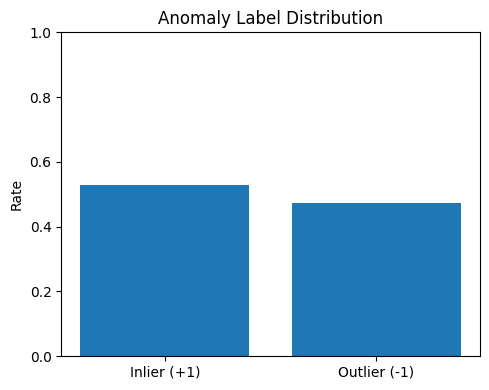

decision_score mean=-22180451.349826, std=217200432.215382, min=-9735312623.371435, max=0.141557


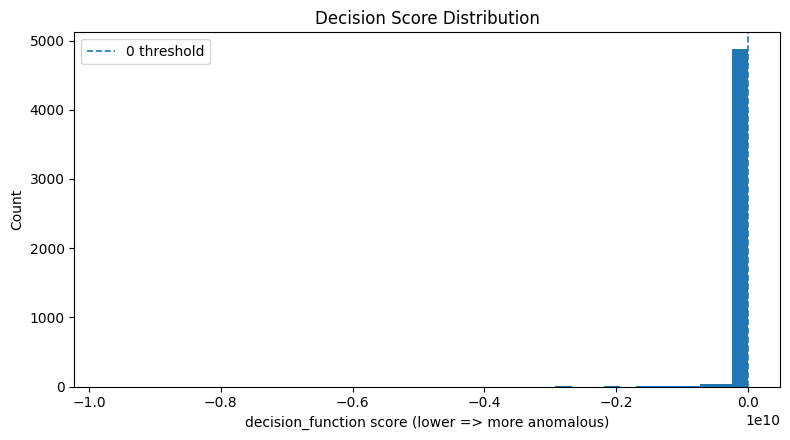

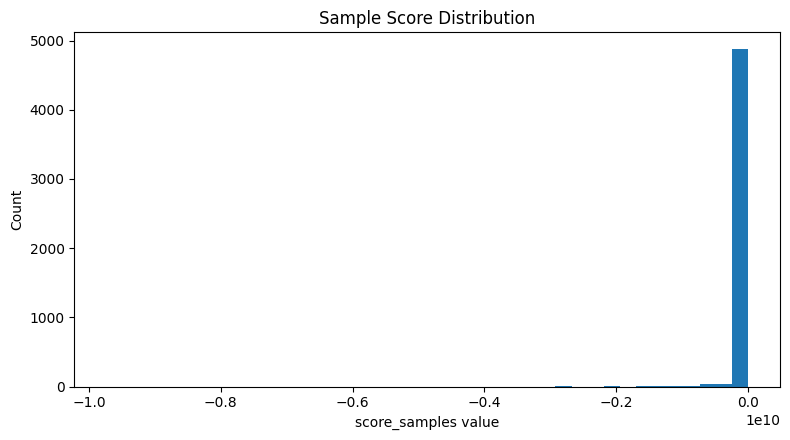

In [ ]:
# Diagnostics + diagrams for anomaly score behavior
if 'INFER_MODEL' not in globals():
    print('Run setup cell first.')
else:
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt

    try:
        split_dir = BASE_DIR / 'splits' / 'UNSW-NB15'
        x_test_csv = split_dir / 'X_test.csv'

        if not x_test_csv.exists():
            raise FileNotFoundError(f'X_test.csv not found at: {x_test_csv}')

        # Load saved test split
        X_eval_df = pd.read_csv(x_test_csv)

        # Match feature count expected by saved model
        expected_n = getattr(INFER_MODEL, 'n_features_in_', None)
        if expected_n is not None:
            if X_eval_df.shape[1] > int(expected_n):
                X_eval_df = X_eval_df.iloc[:, :int(expected_n)]
            elif X_eval_df.shape[1] < int(expected_n):
                raise ValueError(
                    f'Feature mismatch: model expects {int(expected_n)} columns, '
                    f'but X_test.csv has {X_eval_df.shape[1]}'
                )

        X_eval = X_eval_df.values

        n = min(5000, X_eval.shape[0])
        X_sub = X_eval[:n]

        preds = INFER_MODEL.predict(X_sub)
        outlier_rate = float((preds == -1).mean())
        inlier_rate = 1.0 - outlier_rate

        print(f'Samples evaluated: {n}')
        print(f'Outlier rate: {outlier_rate:.4f}')
        print(f'Inlier rate: {inlier_rate:.4f}')

        # Graph 1
        plt.figure(figsize=(5, 4))
        plt.bar(['Inlier (+1)', 'Outlier (-1)'], [inlier_rate, outlier_rate])
        plt.ylim(0, 1)
        plt.title('Anomaly Label Distribution')
        plt.ylabel('Rate')
        plt.tight_layout()
        plt.show()

        # Graph 2
        if hasattr(INFER_MODEL, 'decision_function'):
            d = np.ravel(INFER_MODEL.decision_function(X_sub))
            print(
                f'decision_score mean={float(d.mean()):.6f}, '
                f'std={float(d.std()):.6f}, '
                f'min={float(d.min()):.6f}, '
                f'max={float(d.max()):.6f}'
            )

            plt.figure(figsize=(8, 4.5))
            plt.hist(d, bins=40)
            plt.axvline(0.0, linestyle='--', linewidth=1.2, label='0 threshold')
            plt.title('Decision Score Distribution')
            plt.xlabel('decision_function score (lower => more anomalous)')
            plt.ylabel('Count')
            plt.legend()
            plt.tight_layout()
            plt.show()

        # Graph 3
        if hasattr(INFER_MODEL, 'score_samples'):
            s = np.ravel(INFER_MODEL.score_samples(X_sub))
            plt.figure(figsize=(8, 4.5))
            plt.hist(s, bins=40)
            plt.title('Sample Score Distribution')
            plt.xlabel('score_samples value')
            plt.ylabel('Count')
            plt.tight_layout()
            plt.show()

    except Exception as e:
        print('Diagnostics failed:')
        print(str(e))

In [ ]:
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!jupyter nbconvert --to html --template=classic --no-input /content/drive/MyDrive/MLmodeling/XAI/notebooks_v1/UNSW-NB15/UNSW_16_LOF.ipynb

[NbConvertApp] Converting notebook /content/drive/MyDrive/MLmodeling/XAI/notebooks_v1/UNSW-NB15/UNSW_16_LOF.ipynb to html
Traceback (most recent call last):
  File "/usr/local/bin/jupyter-nbconvert", line 10, in <module>
    sys.exit(main())
             ^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/jupyter_core/application.py", line 284, in launch_instance
    super().launch_instance(argv=argv, **kwargs)
  File "/usr/local/lib/python3.12/dist-packages/traitlets/config/application.py", line 992, in launch_instance
    app.start()
  File "/usr/local/lib/python3.12/dist-packages/nbconvert/nbconvertapp.py", line 420, in start
    self.convert_notebooks()
  File "/usr/local/lib/python3.12/dist-packages/nbconvert/nbconvertapp.py", line 597, in convert_notebooks
    self.convert_single_notebook(notebook_filename)
  File "/usr/local/lib/python3.12/dist-packages/nbconvert/nbconvertapp.py", line 563, in convert_single_notebook
    output, resources = self.export_single_notebook(
      